In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install -q openmm pdbfixer mdtraj

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 665.9/665.9 kB 11.2 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 74.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 88.4 MB/s eta 0:00:00:00:0100:01


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/muhammadanasamer/mhc1-vtn/mhc1_vtn_complex_fixed.pdb


In [9]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:08
🔁 Restarting kernel...


In [1]:
!conda install -y -c conda-forge openmm pdbfixer

Retrieving notices: done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - openmm
    - pdbfixer


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    certifi-2026.7.22          |     pyhd8ed1ab_0         134 KB  conda-forge
    conda-26.3.2               |  py312h7900ff3_1         1.2 MB  conda-forge
    cuda-nvrtc-12.9.86         |       hecca717_1        64.1 MB  conda-forge
    cuda-version-12.9          |       h4f385c5_3          21 KB  conda-forge
    legacy-cgi-2.6.4           |     pyhcf101f3_0          19 KB  conda-forge
    libblas-3.11.0             |11_h4a7cf45_openblas          18 KB  conda-forge
    libcblas-3.11.0            |11_h0358290_openblas          18 KB  conda-forge
    libcufft-11.4.1

In [2]:
!pip install -q pdbfixer
from pdbfixer import PDBFixer
from openmm.app import *
from openmm import *
from openmm.unit import *

# 1. Load the complex into PDBFixer instead of directly into OpenMM
print("Repairing PDB (adding missing terminal OXT atoms and hydrogens)...")
fixer = PDBFixer(filename='/kaggle/input/datasets/muhammadanasamer/mhc1-vtn/mhc1_vtn_complex_fixed.pdb')

# Find missing structure components and add them at pH 7.0
fixer.findMissingResidues()
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(7.0)

# 2. Apply Forcefield and Implicit Solvent (OBC2)
print("Loading forcefields...")
forcefield = ForceField('amber14-all.xml', 'implicit/obc2.xml')

# 3. Create System with Hydrogen Mass Repartitioning (4 amu)
print("Creating system...")
system = forcefield.createSystem(
    fixer.topology,
    nonbondedMethod=NoCutoff,  
    constraints=HBonds,
    hydrogenMass=4*amu         
)

# 4. Configure GPU (P100) and Integrator (4 fs timestep)
integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.004*picoseconds)
platform = Platform.getPlatformByName('CUDA')
properties = {'CudaPrecision': 'mixed'}

# Notice we pass the repaired fixer.topology and fixer.positions
simulation = Simulation(fixer.topology, system, integrator, platform, properties)
simulation.context.setPositions(fixer.positions)

# 5. Minimize Energy
print("Minimizing energy to fix docking clashes...")
simulation.minimizeEnergy()

# 6. Save the minimized state to Kaggle's working directory
with open('/kaggle/working/minimized_complex.pdb', 'w') as f:
    PDBFile.writeFile(simulation.topology, simulation.context.getState(getPositions=True).getPositions(), f)

print("Step 3 Complete: System minimized and saved as minimized_complex.pdb!")

Repairing PDB (adding missing terminal OXT atoms and hydrogens)...
Loading forcefields...
Creating system...
Minimizing energy to fix docking clashes...
Step 3 Complete: System minimized and saved as minimized_complex.pdb!


In [3]:
import sys
from openmm.app import *
from openmm import *
from openmm.unit import *

# 1. Load the minimized complex from Step 3
print("Loading minimized complex...")
pdb = PDBFile('/kaggle/working/minimized_complex.pdb')

# 2. Setup Forcefield and Implicit Solvent
forcefield = ForceField('amber14-all.xml', 'implicit/obc2.xml')

# 3. Create System with Hydrogen Mass Repartitioning (4 amu)
system = forcefield.createSystem(
    pdb.topology,
    nonbondedMethod=NoCutoff,
    constraints=HBonds,
    hydrogenMass=4*amu
)

# 4. Setup Integrator and GPU
integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.004*picoseconds)
platform = Platform.getPlatformByName('CUDA')
properties = {'CudaPrecision': 'mixed'}

simulation = Simulation(pdb.topology, system, integrator, platform, properties)
simulation.context.setPositions(pdb.positions)

# 5. Assign initial velocities and equilibrate for 100 ps (25,000 steps * 4 fs)
print("Assigning velocities at 300 K...")
simulation.context.setVelocitiesToTemperature(300*kelvin)

print("Running 100 ps thermal equilibration...")
simulation.reporters.append(StateDataReporter(sys.stdout, 5000, step=True, 
                                              potentialEnergy=True, temperature=True, speed=True))
simulation.step(25000)

# 6. Save Equilibrated State and PDB structure
simulation.saveState('/kaggle/working/equilibrated_state.xml')
with open('/kaggle/working/equilibrated_complex.pdb', 'w') as f:
    PDBFile.writeFile(simulation.topology, simulation.context.getState(getPositions=True).getPositions(), f)

print("Step 4 Complete: Equilibration finished successfully!")

Loading minimized complex...
Assigning velocities at 300 K...
Running 100 ps thermal equilibration...
#"Step","Potential Energy (kJ/mole)","Temperature (K)","Speed (ns/day)"
5000,-37499.9050645211,301.8393672213048,0
10000,-38295.71729768987,297.02257848328355,339
15000,-38275.76972209485,300.9144763969107,339
20000,-38372.88821689926,297.8960344688624,339
25000,-37880.12506843025,304.6888386560656,339
Step 4 Complete: Equilibration finished successfully!


In [4]:
import sys
from openmm.app import *
from openmm import *
from openmm.unit import *

# 1. Load the equilibrated complex and topology
print("Loading equilibrated system...")
pdb = PDBFile('/kaggle/working/equilibrated_complex.pdb')

forcefield = ForceField('amber14-all.xml', 'implicit/obc2.xml')

# 2. Create System (Standard 2 fs setup: no hydrogenMass override)
system = forcefield.createSystem(
    pdb.topology,
    nonbondedMethod=NoCutoff,
    constraints=HBonds
)

# 3. Setup Integrator (2 fs = 0.002 ps) and GPU Platform
integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.002*picoseconds)
platform = Platform.getPlatformByName('CUDA')
properties = {'CudaPrecision': 'mixed'}

simulation = Simulation(pdb.topology, system, integrator, platform, properties)

# 4. Load Equilibrated State (Preserves exact positions and velocities from Step 4)
simulation.loadState('/kaggle/working/equilibrated_state.xml')

# 5. Execute 40 ns Production Run
print("Initiating 40 ns Production MD with 2 fs timestep...")

# Save a trajectory frame every 10 ps (5,000 steps)
simulation.reporters.append(DCDReporter('/kaggle/working/vtn_complex_40ns.dcd', 5000))

# Print progress to the console every 100 ps (50,000 steps)
simulation.reporters.append(StateDataReporter(sys.stdout, 50000, step=True, 
                                              potentialEnergy=True, temperature=True, speed=True))

# 40,000 ps / 0.002 ps = 20,000,000 steps
simulation.step(20000000)

# 6. Save Final Structure
with open('/kaggle/working/vtn_complex_final.pdb', 'w') as f:
    PDBFile.writeFile(simulation.topology, simulation.context.getState(getPositions=True).getPositions(), f)

print("40 ns MD Simulation Complete!")

Loading equilibrated system...
Initiating 40 ns Production MD with 2 fs timestep...
#"Step","Potential Energy (kJ/mole)","Temperature (K)","Speed (ns/day)"
50000,-37954.024278367186,298.7139858063308,0
100000,-38163.24366179876,303.5547660351244,170
150000,-37831.96531490886,298.205176297819,170
200000,-38424.383318205764,300.0902837079995,170
250000,-38409.12654594033,299.55153021042264,170
300000,-38413.85794749774,298.5567896610182,170
350000,-38108.1604833964,298.84173244696717,170
400000,-38270.5109599081,297.96380540359536,170
450000,-38324.214815659485,299.8819662919906,170
500000,-38293.33365145396,302.81265656335705,170
550000,-38318.499400162415,310.68005973476676,170
600000,-38665.76163210666,300.5650782483881,170
650000,-38637.318510809484,296.34359820199603,170
700000,-38420.21475596187,301.70719693659595,170
750000,-38495.772435443185,302.0669025895669,170
800000,-38485.32689312043,296.9988285686567,170
850000,-38194.73364015338,291.6259179658891,170
900000,-38494.7675422

Loading trajectory...
Calculating RMSD...


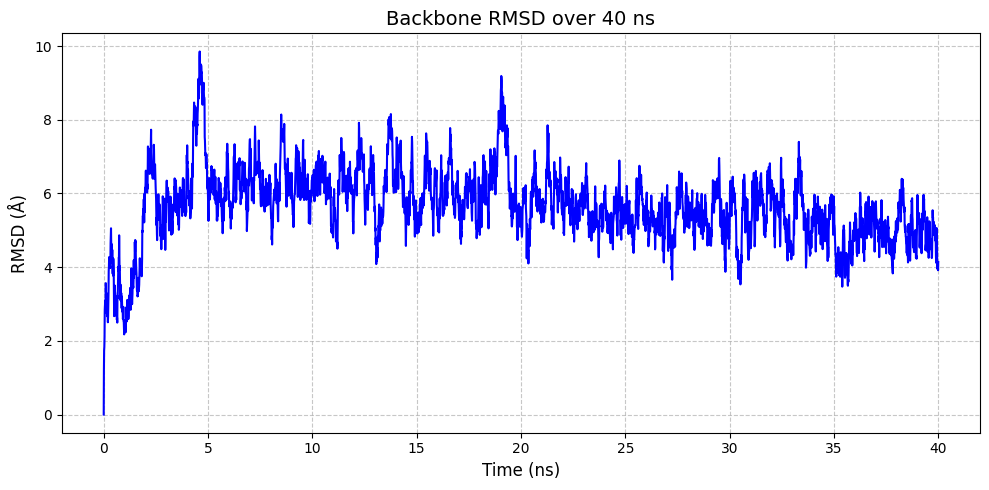

Calculating RMSF...


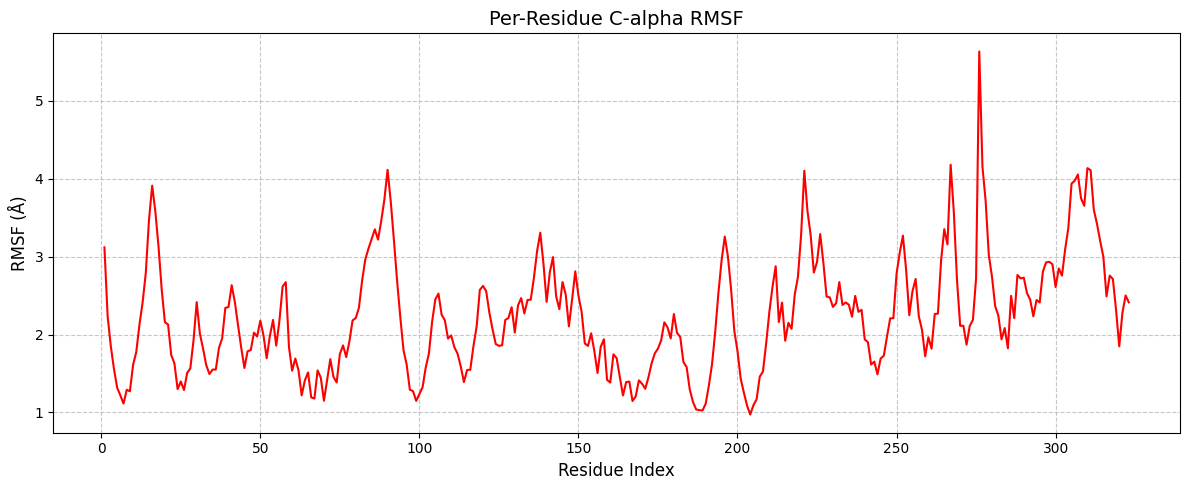

Analysis complete. Plots saved as rmsd_plot.png and rmsf_plot.png


In [5]:
!pip install -q mdtraj matplotlib

import mdtraj as md
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Trajectory and Topology
print("Loading trajectory...")
pdb_file = '/kaggle/working/vtn_complex_final.pdb'
dcd_file = '/kaggle/working/vtn_complex_40ns.dcd'

# Load trajectory and standardise units to Angstroms
traj = md.load(dcd_file, top=pdb_file)
topology = traj.topology

# Select only the alpha-carbons (C-alpha) for the backbone analysis
calpha_indices = topology.select('name CA')
calpha_traj = traj.atom_slice(calpha_indices)

# Superimpose all frames onto the first frame to remove rotational/translational motion
calpha_traj.superpose(calpha_traj, 0)

# 2. Calculate RMSD (Root Mean Square Deviation)
print("Calculating RMSD...")
# Calculate RMSD in nanometers, then convert to Angstroms (x10)
rmsd = md.rmsd(calpha_traj, calpha_traj, 0) * 10 
# Create a time array (1 frame = 10 ps = 0.01 ns)
time_ns = np.arange(len(rmsd)) * 0.01

# Plot RMSD
plt.figure(figsize=(10, 5))
plt.plot(time_ns, rmsd, color='blue', linewidth=1.5)
plt.title('Backbone RMSD over 40 ns', fontsize=14)
plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('RMSD (Å)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/kaggle/working/rmsd_plot.png', dpi=300)
plt.show()

# 3. Calculate RMSF (Root Mean Square Fluctuation)
print("Calculating RMSF...")
# Calculate RMSF in nanometers, convert to Angstroms
rmsf = md.rmsf(calpha_traj, calpha_traj, 0) * 10
residue_numbers = np.arange(1, len(rmsf) + 1)

# Plot RMSF
plt.figure(figsize=(12, 5))
plt.plot(residue_numbers, rmsf, color='red', linewidth=1.5)
plt.title('Per-Residue C-alpha RMSF', fontsize=14)
plt.xlabel('Residue Index', fontsize=12)
plt.ylabel('RMSF (Å)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/kaggle/working/rmsf_plot.png', dpi=300)
plt.show()

print("Analysis complete. Plots saved as rmsd_plot.png and rmsf_plot.png")

Loading trajectory for interaction analysis...
Calculating Radius of Gyration...


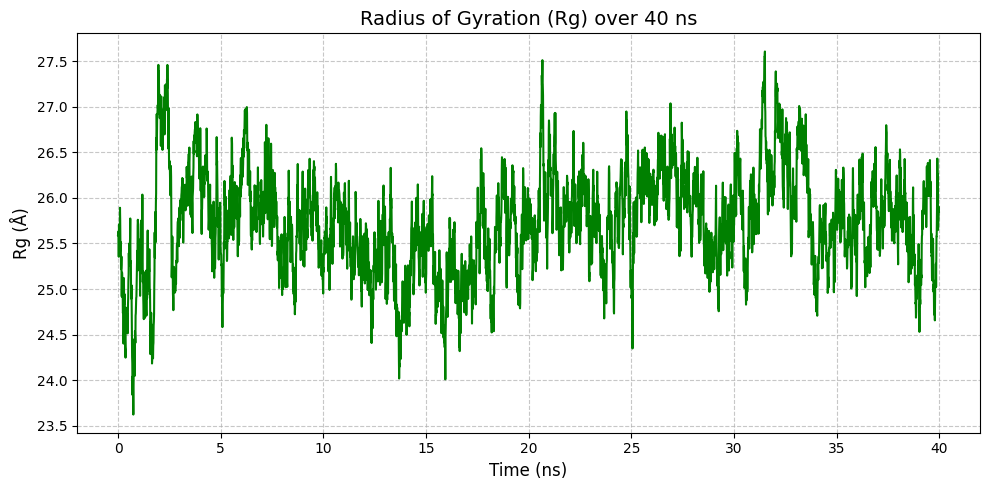

Calculating Intermolecular Hydrogen Bonds...


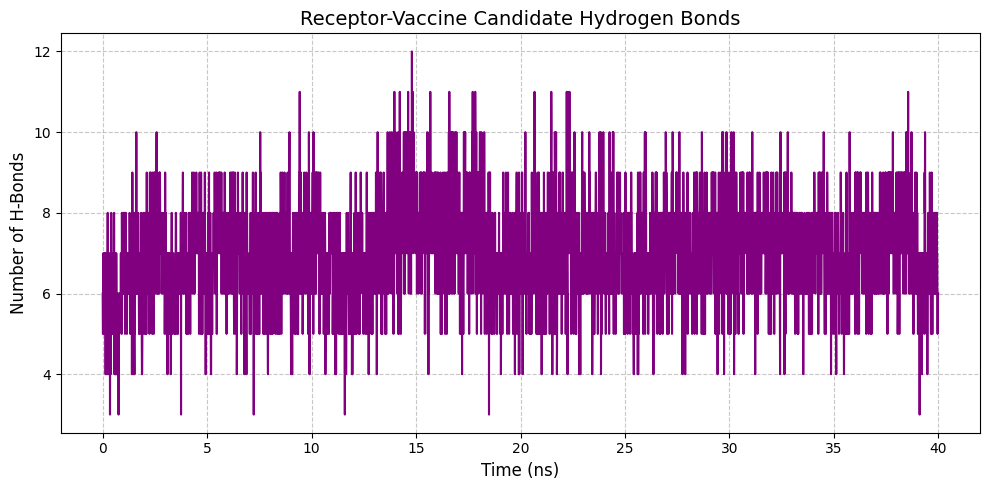

Interaction analysis complete. Plots saved as rg_plot.png and hbond_plot.png


In [6]:
import mdtraj as md
import matplotlib.pyplot as plt
import numpy as np

print("Loading trajectory for interaction analysis...")
pdb_file = '/kaggle/working/vtn_complex_final.pdb'
dcd_file = '/kaggle/working/vtn_complex_40ns.dcd'
traj = md.load(dcd_file, top=pdb_file)
time_ns = np.arange(len(traj)) * 0.01

# 1. Radius of Gyration (Rg)
# Measures if the complex remains folded and tightly packed or if it unfolds/loosens
print("Calculating Radius of Gyration...")
rg = md.compute_rg(traj) * 10 # Convert nanometers to Angstroms

plt.figure(figsize=(10, 5))
plt.plot(time_ns, rg, color='green', linewidth=1.5)
plt.title('Radius of Gyration (Rg) over 40 ns', fontsize=14)
plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('Rg (Å)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/kaggle/working/rg_plot.png', dpi=300)
plt.show()

# 2. Intermolecular Hydrogen Bonds
# Tracks the specific H-bonds forming between the receptor and the VTN domain
print("Calculating Intermolecular Hydrogen Bonds...")
receptor_indices = traj.topology.select('chainid 0')
vtn_peptide_indices = traj.topology.select('chainid 1')

# Calculate all hydrogen bonds in every frame using the Wernet-Nilsson criteria
hbonds = md.wernet_nilsson(traj)

# Filter for bonds strictly between the receptor and the ligand
interchain_hbond_counts = []
for frame in hbonds:
    count = 0
    for bond in frame:
        donor = bond[0]
        acceptor = bond[2] # Index 2 is the acceptor heavy atom
        if (donor in receptor_indices and acceptor in vtn_peptide_indices) or \
           (donor in vtn_peptide_indices and acceptor in receptor_indices):
            count += 1
    interchain_hbond_counts.append(count)

plt.figure(figsize=(10, 5))
plt.plot(time_ns, interchain_hbond_counts, color='purple', linewidth=1.5)
plt.title('Receptor-Vaccine Candidate Hydrogen Bonds', fontsize=14)
plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('Number of H-Bonds', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/kaggle/working/hbond_plot.png', dpi=300)
plt.show()

print("Interaction analysis complete. Plots saved as rg_plot.png and hbond_plot.png")